## 1. Environment Setup

In [1]:
# Core libraries
import os
import json
import time
import random
import shutil
from pathlib import Path
from collections import defaultdict, Counter

import cv2
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from skimage.restoration import wiener, richardson_lucy

from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd()
COCO_ROOT = PROJECT_ROOT / "coco"

BLUR_DIR = COCO_ROOT / "blur"
SHARP_DIR = COCO_ROOT / "sharp"
LABEL_JSON_PATH = COCO_ROOT / "label" / "instances_val2017.json"

OUTPUT_ROOT = PROJECT_ROOT / "outputs"
DEBLUR_ROOT = OUTPUT_ROOT / "deblur"
ANALYSIS_ROOT = OUTPUT_ROOT / "analysis"
PROCESSED_ROOT = OUTPUT_ROOT / "processed_dataset"
RUNS_ROOT = OUTPUT_ROOT / "runs"

for p in [OUTPUT_ROOT, DEBLUR_ROOT, ANALYSIS_ROOT, PROCESSED_ROOT, RUNS_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("BLUR_DIR exists:", BLUR_DIR.exists())
print("SHARP_DIR exists:", SHARP_DIR.exists())
print("LABEL_JSON_PATH exists:", LABEL_JSON_PATH.exists())

PROJECT_ROOT: C:\Users\90616\Desktop\CV
BLUR_DIR exists: True
SHARP_DIR exists: True
LABEL_JSON_PATH exists: True


## 2. Load Blur and Sharp Images

In [2]:
VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

blur_files = sorted([p.name for p in BLUR_DIR.iterdir() if p.is_file() and p.suffix.lower() in VALID_EXTS])
sharp_files = sorted([p.name for p in SHARP_DIR.iterdir() if p.is_file() and p.suffix.lower() in VALID_EXTS])

blur_set = set(blur_files)
sharp_set = set(sharp_files)

common_files = sorted(blur_set & sharp_set)
blur_only = sorted(blur_set - sharp_set)
sharp_only = sorted(sharp_set - blur_set)

pair_df = pd.DataFrame({
    "file_name": common_files
})

print("Blur images  :", len(blur_files))
print("Sharp images :", len(sharp_files))
print("Matched pairs:", len(common_files))
print("Blur only    :", len(blur_only))
print("Sharp only   :", len(sharp_only))

if blur_only:
    print("\nFirst 10 blur-only files:", blur_only[:10])

if sharp_only:
    print("\nFirst 10 sharp-only files:", sharp_only[:10])

pair_df.head()

Blur images  : 200
Sharp images : 200
Matched pairs: 200
Blur only    : 0
Sharp only   : 0


,file_name
0,000000015335.jpg
1,000000016598.jpg
2,000000017905.jpg
3,000000018150.jpg
4,000000018193.jpg


## 3. Pair Consistency Check

In [3]:
def read_bgr(path: Path):
    img = cv2.imread(str(path))
    if img is None:
        raise ValueError(f"Failed to read image: {path}")
    return img

size_rows = []
bad_pairs = []

for file_name in common_files:
    blur_path = BLUR_DIR / file_name
    sharp_path = SHARP_DIR / file_name
    try:
        blur_img = read_bgr(blur_path)
        sharp_img = read_bgr(sharp_path)
        size_rows.append({
            "file_name": file_name,
            "blur_h": blur_img.shape[0],
            "blur_w": blur_img.shape[1],
            "sharp_h": sharp_img.shape[0],
            "sharp_w": sharp_img.shape[1],
            "same_shape": blur_img.shape[:2] == sharp_img.shape[:2]
        })
    except Exception as e:
        bad_pairs.append((file_name, str(e)))

size_df = pd.DataFrame(size_rows)
display(size_df.head())

print("Pairs with same shape:", int(size_df["same_shape"].sum()), "/", len(size_df))
print("Unreadable pairs:", len(bad_pairs))
if bad_pairs:
    print(bad_pairs[:5])

,file_name,blur_h,blur_w,sharp_h,sharp_w,same_shape
0,000000015335.jpg,480,640,480,640,True
1,000000016598.jpg,640,478,640,478,True
2,000000017905.jpg,640,480,640,480,True
3,000000018150.jpg,480,640,480,640,True
4,000000018193.jpg,480,640,480,640,True


Pairs with same shape: 200 / 200
Unreadable pairs: 0


## 4. Preview Blur–Sharp Examples

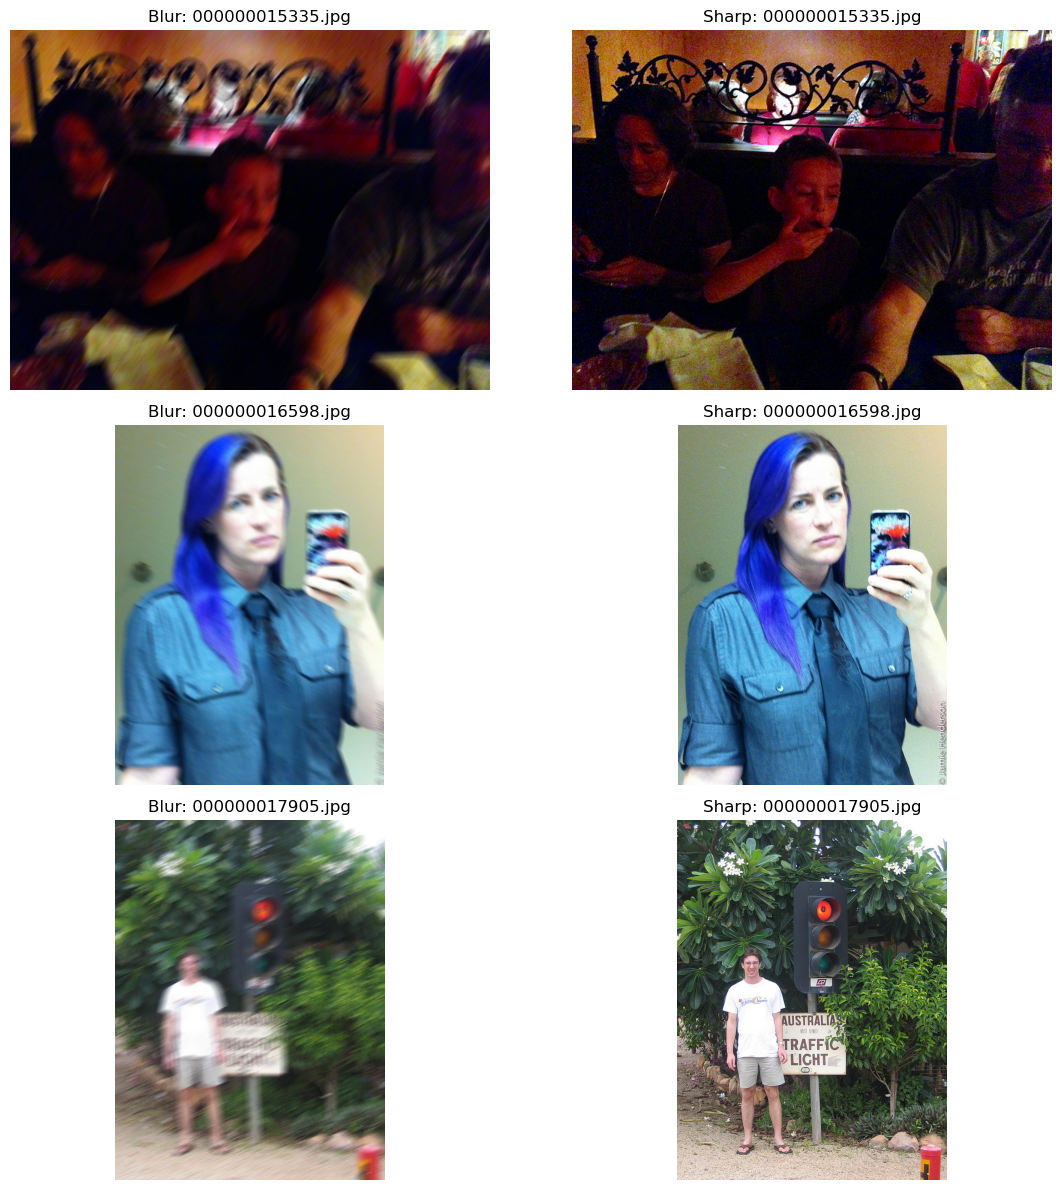

In [4]:
def show_pair_examples(file_names, n=3):
    n = min(n, len(file_names))
    chosen = file_names[:n]
    plt.figure(figsize=(12, 4 * n))
    for i, file_name in enumerate(chosen, start=1):
        blur_img = cv2.cvtColor(read_bgr(BLUR_DIR / file_name), cv2.COLOR_BGR2RGB)
        sharp_img = cv2.cvtColor(read_bgr(SHARP_DIR / file_name), cv2.COLOR_BGR2RGB)

        plt.subplot(n, 2, 2*i - 1)
        plt.imshow(blur_img)
        plt.title(f"Blur: {file_name}")
        plt.axis("off")

        plt.subplot(n, 2, 2*i)
        plt.imshow(sharp_img)
        plt.title(f"Sharp: {file_name}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_pair_examples(common_files, n=3)

## 5. Helper Functions for Metrics, Blur Score, and Visualisation

In [5]:
def bgr_to_rgb(img_bgr):
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

def rgb_metrics(reference_rgb, test_rgb):
    psnr = peak_signal_noise_ratio(reference_rgb, test_rgb, data_range=255)
    ssim = structural_similarity(reference_rgb, test_rgb, channel_axis=2, data_range=255)
    mse = np.mean((reference_rgb.astype(np.float32) - test_rgb.astype(np.float32)) ** 2)
    return mse, psnr, ssim

def estimate_blur_score(image_bgr):
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

def summarize_image(file_name):
    blur_bgr = read_bgr(BLUR_DIR / file_name)
    sharp_bgr = read_bgr(SHARP_DIR / file_name)
    return {
        "file_name": file_name,
        "height": blur_bgr.shape[0],
        "width": blur_bgr.shape[1],
        "blur_score_blur_img": estimate_blur_score(blur_bgr),
        "blur_score_sharp_img": estimate_blur_score(sharp_bgr)
    }

## 6. Estimate Blur Levels for Stratified Splitting

In [6]:
meta_rows = [summarize_image(f) for f in common_files]
meta_df = pd.DataFrame(meta_rows)

# lower Laplacian variance usually means blurrier
meta_df["blur_rank_quantile"] = pd.qcut(
    meta_df["blur_score_blur_img"].rank(method="first"),
    q=min(3, len(meta_df)),
    labels=["low_detail", "mid_detail", "high_detail"]
)

display(meta_df.head())
display(meta_df["blur_rank_quantile"].value_counts(dropna=False))

,file_name,height,width,blur_score_blur_img,blur_score_sharp_img,blur_rank_quantile
0,000000015335.jpg,480,640,66.384762,1106.785073,mid_detail
1,000000016598.jpg,640,478,50.775974,990.058926,low_detail
2,000000017905.jpg,640,480,225.666832,5694.710747,high_detail
3,000000018150.jpg,480,640,44.198844,1045.702389,low_detail
4,000000018193.jpg,480,640,626.975163,4849.039475,high_detail


blur_rank_quantile
low_detail     67
high_detail    67
mid_detail     66
Name: count, dtype: int64

## 7. Define Deblurring Methods

In [7]:
def unsharp_mask(image_bgr, kernel_size=(5, 5), sigma=1.2, amount=1.5):
    blurred = cv2.GaussianBlur(image_bgr, kernel_size, sigma)
    sharpened = cv2.addWeighted(image_bgr, 1 + amount, blurred, -amount, 0)
    return np.clip(sharpened, 0, 255).astype(np.uint8)

def motion_psf(length=13, angle=0):
    kernel = np.zeros((length, length), dtype=np.float32)
    kernel[length // 2, :] = 1.0
    center = (length / 2 - 0.5, length / 2 - 0.5)
    rot = cv2.getRotationMatrix2D(center, angle, 1.0)
    kernel = cv2.warpAffine(kernel, rot, (length, length))
    kernel /= kernel.sum() if kernel.sum() != 0 else 1.0
    return kernel

def wiener_deblur(image_bgr, psf=None, balance=0.03):
    if psf is None:
        psf = motion_psf(length=13, angle=0)
    image_rgb = bgr_to_rgb(image_bgr).astype(np.float32) / 255.0
    out = []
    for c in range(3):
        channel = wiener(image_rgb[:, :, c], psf, balance=balance)
        channel = np.clip(channel, 0, 1)
        out.append(channel)
    restored = np.stack(out, axis=2)
    restored = (restored * 255).astype(np.uint8)
    return cv2.cvtColor(restored, cv2.COLOR_RGB2BGR)

def rl_deblur(image_bgr, psf=None, num_iter=10):
    if psf is None:
        psf = motion_psf(length=13, angle=0)
    image_rgb = bgr_to_rgb(image_bgr).astype(np.float32) / 255.0
    out = []
    for c in range(3):
        channel = richardson_lucy(image_rgb[:, :, c], psf, num_iter=num_iter, clip=False)
        channel = np.clip(channel, 0, 1)
        out.append(channel)
    restored = np.stack(out, axis=2)
    restored = (restored * 255).astype(np.uint8)
    return cv2.cvtColor(restored, cv2.COLOR_RGB2BGR)

RESTORATION_METHODS = {
    "unsharp": lambda img: unsharp_mask(img, kernel_size=(5, 5), sigma=1.2, amount=1.5),
    "wiener": lambda img: wiener_deblur(img, psf=motion_psf(length=13, angle=0), balance=0.03),
    "richardson_lucy": lambda img: rl_deblur(img, psf=motion_psf(length=13, angle=0), num_iter=10),
}

## 8. Compare Deblurring Methods on a Representative Subset